In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import LabelEncoder

# Configurações de Pastas
PATH_INERTIAL = "/content/drive/MyDrive/2025/Estudos/Datasets/utd-mhad/Inertial/Inertial"
PATH_SKELETON = "/content/drive/MyDrive/2025/Estudos/Datasets/utd-mhad/Skeleton/Skeleton"

# Função de Carga Unitária (Carrega 1 arquivo para EDA)
def load_sample_file(action, subject, trial):
    f_iner = os.path.join(PATH_INERTIAL, f"a{action}_s{subject}_t{trial}_inertial.mat")
    f_skel = os.path.join(PATH_SKELETON, f"a{action}_s{subject}_t{trial}_skeleton.mat")

    if not os.path.exists(f_iner) or not os.path.exists(f_skel):
        print("Arquivo não encontrado.")
        return None, None

    # Carregar
    d_iner = loadmat(f_iner)['d_iner']  # (N, 6) -> Acc(3), Gyro(3)
    d_skel = loadmat(f_skel)['d_skel']  # (M, 20, 3) -> 20 joints, xyz

    # Flatten Skeleton: (M, 20, 3) -> (M, 60)
    M = d_skel.shape[0]
    d_skel_flat = d_skel.reshape(M, -1)

    # Sincronização (Interpolação Linear Skeleton para bater com Inertial)
    N = d_iner.shape[0]
    if M != N:
        f = interp1d(np.linspace(0, 1, M), d_skel_flat, axis=0)
        d_skel_resampled = f(np.linspace(0, 1, N))
    else:
        d_skel_resampled = d_skel_flat

    return d_iner, d_skel_resampled

# Carregar um exemplo para análise (Ação 1: Swipe Right, Sujeito 1)
raw_iner, raw_skel = load_sample_file(action=1, subject=1, trial=1)
print(f"Shape Inertial: {raw_iner.shape}")
print(f"Shape Skeleton (Interpolated): {raw_skel.shape}")

Shape Inertial: (160, 6)
Shape Skeleton (Interpolated): (160, 144)


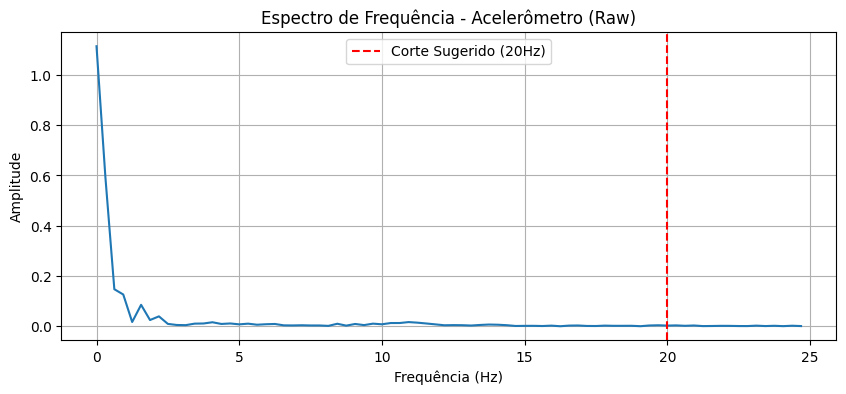

In [4]:
def plot_frequency_spectrum(signal, fs, title):
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)[:n//2]

    plt.figure(figsize=(10, 4))
    plt.plot(xf, 2.0/n * np.abs(yf[0:n//2]))
    plt.title(title)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.axvline(x=20, color='r', linestyle='--', label='Corte Sugerido (20Hz)')
    plt.legend()
    plt.show()

# Analisando Acelerômetro Eixo X
if raw_iner is not None:
    acc_x = raw_iner[:, 0]
    plot_frequency_spectrum(acc_x, 50.0, "Espectro de Frequência - Acelerômetro (Raw)")

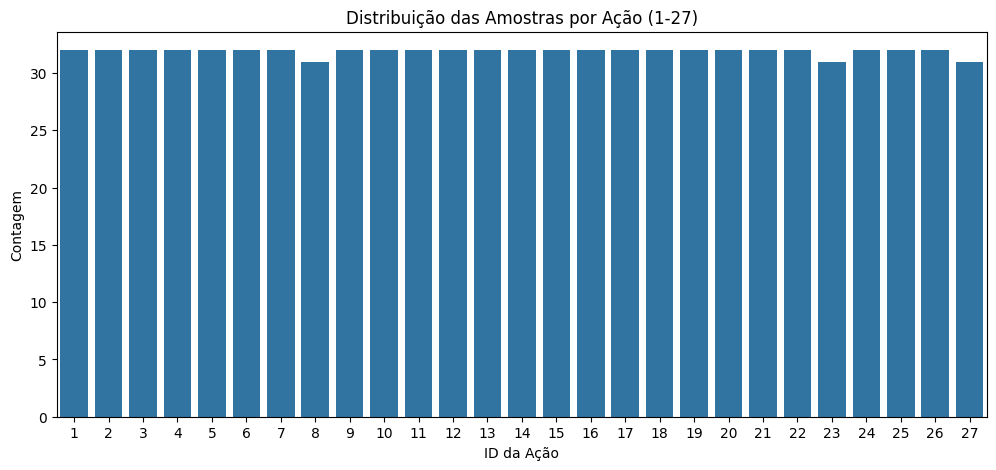

In [5]:
# Contagem rápida sem carregar tudo na memória
action_counts = []
files = glob.glob(os.path.join(PATH_INERTIAL, "*.mat"))

for f in files:
    # Nome: aXX_sXX_tXX...
    action_id = int(os.path.basename(f).split('_')[0].replace('a', ''))
    action_counts.append(action_id)

plt.figure(figsize=(12, 5))
sns.countplot(x=action_counts)
plt.title("Distribuição das Amostras por Ação (1-27)")
plt.xlabel("ID da Ação")
plt.ylabel("Contagem")
plt.show()

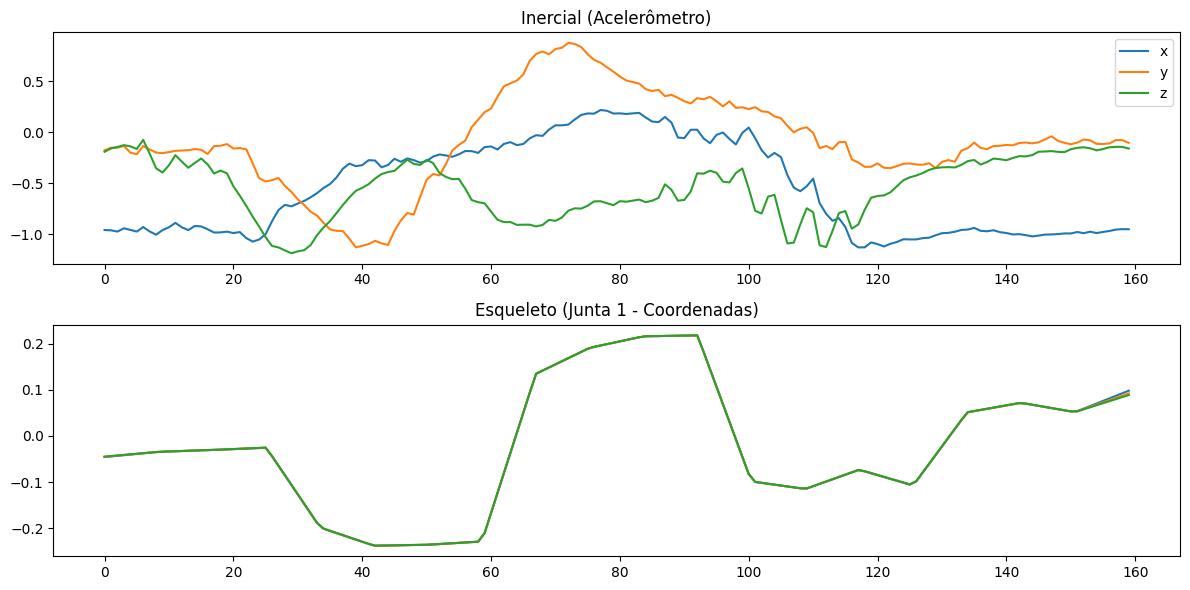

In [6]:
plt.figure(figsize=(12, 6))
# Plot Acelerômetro
plt.subplot(2, 1, 1)
plt.plot(raw_iner[:, :3])
plt.title("Inercial (Acelerômetro)")
plt.legend(['x', 'y', 'z'])

# Plot Esqueleto (Mão Direita - geralmente colunas 11, 12, 13 no formato UTD, mas variando)
# Pegando as primeiras 3 colunas do esqueleto apenas para exemplo
plt.subplot(2, 1, 2)
plt.plot(raw_skel[:, :3])
plt.title("Esqueleto (Junta 1 - Coordenadas)")
plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# PIPELINE COMPLETO
# ==========================================

# Parâmetros definidos pela EDA
FS = 50.0

# Janelamento 2.5s com 50% de Overlap
WINDOW_SIZE = 125  # 2.5 segundos (50Hz)
STEP_SIZE = 62     # 50% overlap

# Split Subject-Independent com Validação
TRAIN_SUBJECTS = [1, 3, 5]
VAL_SUBJECTS = [7] # Validação separada para evitar Biomechanical Bias
TEST_SUBJECTS = [2, 4, 6, 8]

def create_dataset_pipeline():
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    files_iner = glob.glob(os.path.join(PATH_INERTIAL, "*.mat"))
    print(f"Total de arquivos encontrados: {len(files_iner)}")

    EXPECTED_FEATURES = None

    for f_iner in files_iner:
        filename = os.path.basename(f_iner)
        parts = filename.split('_')
        if len(parts) < 3: continue

        action = int(parts[0].replace('a', ''))
        subject = int(parts[1].replace('s', ''))
        trial = parts[2]

        f_skel = os.path.join(PATH_SKELETON, f"a{action}_s{subject}_{trial}_skeleton.mat")
        if not os.path.exists(f_skel): continue

        try:
            # --- 1. CARGA ---
            d_iner = loadmat(f_iner)['d_iner'] # (N_iner, 6)
            d_skel_raw = loadmat(f_skel)['d_skel'] # (20, 3, N_skel)

            # --- 2. CORREÇÃO DE DIMENSÃO ---
            if d_skel_raw.shape[0] == 20 and d_skel_raw.shape[1] == 3:
                d_skel_raw = d_skel_raw.transpose(2, 0, 1)

            # shape (Frames, 20, 3) -> Flatten (Frames, 60)
            d_skel_flat = d_skel_raw.reshape(d_skel_raw.shape[0], -1)

            # --- 3. SINCRONIZAÇÃO (Interpolação em vez de resample) ---
            N = d_iner.shape[0]
            M = d_skel_flat.shape[0]
            if M != N:
                f_interp = interp1d(np.linspace(0, 1, M), d_skel_flat, axis=0)
                d_skel_flat = f_interp(np.linspace(0, 1, N))

            # --- 4. FUSÃO ---
            raw_data = np.hstack([d_iner, d_skel_flat])

            # --- CHECAGEM DE SEGURANÇA ---
            if EXPECTED_FEATURES is None:
                EXPECTED_FEATURES = raw_data.shape[1]
                print(f"--> Padrão corrigido: {EXPECTED_FEATURES} colunas (6 Inertial + 60 Skeleton).")

            if raw_data.shape[1] != EXPECTED_FEATURES:
                print(f"[ERRO] {filename}: {raw_data.shape[1]} colunas.")
                continue

            # --- 5. JANELAMENTO (Sinal Bruto) ---
            num_samples = raw_data.shape[0]
            if num_samples < WINDOW_SIZE: continue

            for start in range(0, num_samples - WINDOW_SIZE + 1, STEP_SIZE):
                window = raw_data[start : start + WINDOW_SIZE, :]

                if subject in TRAIN_SUBJECTS:
                    X_train.append(window)
                    y_train.append(action)
                elif subject in VAL_SUBJECTS:
                    X_val.append(window)
                    y_val.append(action)
                elif subject in TEST_SUBJECTS:
                    X_test.append(window)
                    y_test.append(action)

        except Exception as e:
            print(f"Erro em {filename}: {e}")
            continue

    print(f"\nConcluído!")

    # Conversão para arrays e otimização imediata para float32
    X_train = np.array(X_train, dtype=np.float32)
    X_val = np.array(X_val, dtype=np.float32)
    X_test = np.array(X_test, dtype=np.float32)

    # Ajuste de classe (0-indexed)
    y_train = np.array(y_train) - 1
    y_val = np.array(y_val) - 1
    y_test = np.array(y_test) - 1

    return X_train, y_train, X_val, y_val, X_test, y_test

In [8]:
import os

# Recuperar os dados da função anterior
X_train, y_train, X_val, y_val, X_test, y_test = create_dataset_pipeline()

# Dimensões
N_tr, T, F = X_train.shape
N_va, _, _ = X_val.shape
N_te, _, _ = X_test.shape

# --- DEFINIÇÃO DO CAMINHO DE SAÍDA ---
OUTPUT_DIR = "/content/drive/MyDrive/2025/Estudos/Datasets/utd-mhad"

# Garantir que a pasta existe
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Diretório criado: {OUTPUT_DIR}")

output_filename = os.path.join(OUTPUT_DIR, "utd_mhad_for_rp.npz")

# Salvar Arquivo Final (sem normalização)
np.savez_compressed(
    output_filename,
    X_train=X_train.astype(np.float32),
    y_train=y_train,
    X_val=X_val.astype(np.float32),
    y_val=y_val,
    X_test=X_test.astype(np.float32),
    y_test=y_test
)

print(f"\nArquivo salvo com sucesso em: {output_filename}")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")

Total de arquivos encontrados: 861
--> Padrão corrigido: 66 colunas (6 Inertial + 60 Skeleton).

Concluído!

Arquivo salvo com sucesso em: /content/drive/MyDrive/2025/Estudos/Datasets/utd-mhad/utd_mhad_for_rp.npz
   X_train: (457, 125, 66)
   X_val:   (145, 125, 66)
   X_test:  (623, 125, 66)
